# Model Training

## Import packages

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import pearsonr

# Modelling
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

## Load and pre-process data

We start by importing the 3 datasets and pre-processing it as described in the `EDA.ipynb` notebook:

In [4]:
drug_synergy_df=pd.read_csv('../data/drug_synergy.csv')
print('Drug synergy size: ' + str(drug_synergy_df.shape))

cell_lines_df=pd.read_csv('../data/cell_lines.csv')
print('Cell lines dataset size: ' + str(cell_lines_df.shape))

drug_portfolio_df=pd.read_csv('../data/drug_portfolio.csv', sep='\t')
print('Drug portfolio dataset size: ' + str(drug_portfolio_df.shape))

Drug synergy size: (3879, 16)
Cell lines dataset size: (159, 10)
Drug portfolio dataset size: (118, 11)


now we do quality control and feature engineering, also according to the `EDA.ipynb` noteebok:

In [5]:
#quality filtering
drug_synergy_df = drug_synergy_df[drug_synergy_df.QA==1]
drug_synergy_df

#missing vals fitlering
drug_synergy_bool = (drug_synergy_df.isna().sum() < len(drug_synergy_df)*0.2).values #logical vector, T if less than 20% missing values
cell_lines_df_bool = (cell_lines_df.isna().sum() < len(cell_lines_df)*0.2).values
drug_portfolio_df_bool = (drug_portfolio_df.isna().sum() < len(drug_portfolio_df)*0.2).values

drug_synergy_df = drug_synergy_df[ drug_synergy_df.columns[drug_synergy_bool] ]
cell_lines_df = cell_lines_df[ cell_lines_df.columns[cell_lines_df_bool] ]
drug_portfolio_df = drug_portfolio_df[ drug_portfolio_df.columns[drug_portfolio_df_bool] ]

#irrelevant features filtering
badfeats = ['Challenge', 'QA', 'COSMIC ID', 'GDSC tissue descriptor 1', 'TCGA','Dataset','Combination ID']

#filter irrelevant features
def filterfunc( df ):
    ''' Takes a df and checks its cols, if they in badfeats, they are removed '''
    tobedropped = []
    for col in df.columns:
        if col in badfeats:
            tobedropped.append(col)
    
    df = df.drop( tobedropped, axis=1 )
    return df

drug_synergy_df = filterfunc(drug_synergy_df)
cell_lines_df = filterfunc(cell_lines_df)
drug_portfolio_df = filterfunc(drug_portfolio_df)

#cell line, drugA and drug B dfs
cell_lines_df = cell_lines_df[ ['Cell line name', 'GDSC tissue descriptor 2', 'MSI', 'Growth properties'] ]
cell_lines_df.drop_duplicates( inplace=True ) #as we removed some columns, we might have duplicate rows

drug_portfolio_df_A = drug_portfolio_df[ ['Challenge drug name', 'Putative target','Function', 'Pathway'] ]
drug_portfolio_df_A.columns = ['Compound A', 'Putative target A','Function A', 'Pathway A'] #rename (notice we use 'Challenge drug name' and not 'Drug name')
drug_portfolio_df_A.drop_duplicates( inplace=True )

drug_portfolio_df_B = drug_portfolio_df[ ['Challenge drug name', 'Putative target','Function', 'Pathway'] ]
drug_portfolio_df_B.columns = ['Compound B', 'Putative target B','Function B', 'Pathway B'] #rename
drug_portfolio_df_B.drop_duplicates( inplace=True )

#join on drug combination df
df = pd.merge( drug_synergy_df, cell_lines_df, on='Cell line name' ) #create df and add cell line info
df = pd.merge( df, drug_portfolio_df_A, on='Compound A' ) #add drug A info
df = pd.merge( df, drug_portfolio_df_B, on='Compound B' ) #add drug B info

print( 'Drug synergy related features:' )
print(*drug_synergy_df.columns, sep=", ")
print( '-----------------------------------------------------------------------------------------------------------------' )

print( 'Cell line related features:' )
print(*cell_lines_df.columns, sep=", ")
print( '-----------------------------------------------------------------------------------------------------------------' )


print( 'Drug related features:' )
print(*drug_portfolio_df_A.columns, sep=", ")
print( '-----------------------------------------------------------------------------------------------------------------' )

print('\n' )
print( 'Final dataframe:' + str(df.shape) )
df.head()

Drug synergy related features:
Cell line name, Compound A, Compound B, Max. conc. A, Max. conc. B, IC50 A, H A, Einf A, IC50 B, H B, Einf B, Synergy score
-----------------------------------------------------------------------------------------------------------------
Cell line related features:
Cell line name, GDSC tissue descriptor 2, MSI, Growth properties
-----------------------------------------------------------------------------------------------------------------
Drug related features:
Compound A, Putative target A, Function A, Pathway A
-----------------------------------------------------------------------------------------------------------------


Final dataframe:(3475, 21)


,Cell line name,Compound A,Compound B,Max. conc. A,Max. conc. B,IC50 A,H A,Einf A,IC50 B,H B,...,Synergy score,GDSC tissue descriptor 2,MSI,Growth properties,Putative target A,Function A,Pathway A,Putative target B,Function B,Pathway B
0,BT-20,AKT,ADAM17,1.0,75.0,1.000000,0.809002,59.122436,9.639714,0.757977,...,29.540390,breast,MSS/MSI-L,Adherent,AKT1;AKT2;AKT3,Oncogenic signal,AKT/PI3K,ADAM17,Differentiation,EMT/migration
1,CAL-51,AKT,ADAM17,1.0,75.0,1.000000,0.726984,11.150843,75.000000,0.375043,...,0.315422,breast,MSS/MSI-L,Adherent,AKT1;AKT2;AKT3,Oncogenic signal,AKT/PI3K,ADAM17,Differentiation,EMT/migration
2,HCC1187,AKT,ADAM17,1.0,75.0,0.410029,1.496901,51.921265,1.000000,0.000000,...,-0.801993,breast,MSS/MSI-L,Suspension,AKT1;AKT2;AKT3,Oncogenic signal,AKT/PI3K,ADAM17,Differentiation,EMT/migration
3,HCC1806,AKT,ADAM17,1.0,75.0,0.313992,10.000000,63.399635,75.000000,0.392570,...,-26.733250,breast,MSS/MSI-L,Adherent,AKT1;AKT2;AKT3,Oncogenic signal,AKT/PI3K,ADAM17,Differentiation,EMT/migration
4,HCC1937,AKT,ADAM17,1.0,75.0,1.000000,0.771830,41.529554,1.677924,1.119487,...,32.165520,breast,MSS/MSI-L,Adherent,AKT1;AKT2;AKT3,Oncogenic signal,AKT/PI3K,ADAM17,Differentiation,EMT/migration


## Model creation

We craete a dataframe `X` for the predictor varaibles and another one `y` for the synergy score:

In [6]:
#create dfs for features and output
X = df.drop(['Synergy score'], axis=1) 
y = df['Synergy score']


and split the data for training and testing:

In [7]:
#split data into train and test
X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.2,random_state=42 ) #chose some random state for reproducibility

print( 'Training data: ' + str(X_train.shape) )
print( 'Testing data: ' + str(X_test.shape) )

Training data: (2780, 20)
Testing data: (695, 20)


## Feature transformation

As we are dealing with categorical and numerical variables, we need to process them differently. We use one-hot-encoding for the categorical variables and standarize the numerical ones:

In [8]:
#feature transformation

#identify cat and num vars
catfeats = X.select_dtypes( include="str" ).columns #categorical features
numfeats = X.select_dtypes( include="number" ).columns #numerical features

#define transformation pipeline
cattransformer = OneHotEncoder() #one-hot-encode cat vars
numtransformer = StandardScaler() #normalize num vars

preprocessor = ColumnTransformer( 
    [
        ("OneHotEncoder", cattransformer, catfeats),
         ("StandardScaler", numtransformer, numfeats), 
    ]
) #processes subsets of features differently, then merges them into a single feature space

and we apply it to our training and testing subsets:

In [9]:
#apply transformer to data

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print( 'Training data: ' + str(X_train_transformed.shape) )
print( 'Testing data: ' + str(X_test_transformed.shape) )

Training data: (2780, 333)
Testing data: (695, 333)


### Training and evaluation

Here we use the suggested metric from the paper, weighted Pearson correlation $\rho_w$:

$ \rho_w = \dfrac{\sum_{i=1}^N \sqrt{n_i - 1} \rho_i}{\sum_{i=1}^N \sqrt{n_i - 1}{}} $

where:
* $\rho_i$ is the Pearson correlation coeficient between the predicted and the experimental synergy scores, for drug combination $i$
* $n_i$ is the number of cell lines tested with drug combination $i$
* $N$ is the total number of drug combinations

Remember each drug combination $i$ is tested in several cell lines, so the idea is to compare predicted and experimental scores across them, using correlation. Then we average across all combinations (with a small correction that accounts for the different number of cell lines each combination is tested on)

In [10]:
#weighted pearson corr function
def weighted_pearson(df, combs_col='Combination', exp_col='Experimental', pred_col='Predicted'):
    ''' Computes weighted pearson correlation coefficient between predictions and experiments. Requires an input df
     with 3 cols: drug combination, experimental score, predicted score '''
    weighted_sum = 0
    weight_total = 0
    skipped = 0
    
    for combo, group in df.groupby(combs_col):
        n_i = len(group)
        if n_i <= 1:
            skipped += 1
            continue
        rho_i, _ = pearsonr(group[exp_col], group[pred_col])
        weight = np.sqrt(n_i - 1)
        weighted_sum += weight * rho_i
        weight_total += weight
    
    if weight_total == 0:
        return np.nan
    return weighted_sum / weight_total

and finally, train, test and evaluate the models:

In [11]:
#list all drug combs in training and testing subsets
combs_train = X_train['Compound A'].astype(str) + "+" + X_train['Compound B'].astype(str)
combs_test = X_test['Compound A'].astype(str) + "+" + X_test['Compound B'].astype(str)

#dicc of models
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree Regressor": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGB Regressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False, allow_writing_files=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = []
train_wpc_list = []
test_wpc_list = []

#loop through models
for model_name, model in models.items(): #loop through dicc
    
    #train
    model.fit( X_train_transformed, y_train )
    
    #predict
    y_train_pred = model.predict(X_train_transformed)
    y_test_pred = model.predict(X_test_transformed)
    
    #evaluate with wpc

    #create dfs for wpc function
    df_train_eval = pd.DataFrame({
        'Combination': combs_train,
        'Experimental': y_train.values,
        'Predicted': y_train_pred
    })
    df_test_eval = pd.DataFrame({
        'Combination': combs_test,
        'Experimental': y_test.values,
        'Predicted': y_test_pred
    })
    
    #apply wpc function
    train_wpc = weighted_pearson(df_train_eval) 
    test_wpc = weighted_pearson(df_test_eval)
    
    model_list.append(model_name)
    train_wpc_list.append(train_wpc)
    test_wpc_list.append(test_wpc)

# --- Summarize results in a DataFrame ---
results_df = pd.DataFrame({
    'Model Name': model_list,
    'Train WPC': train_wpc_list,
    'Test WPC': test_wpc_list
}).sort_values(by="Test WPC", ascending=False)

results_df

/var/folders/hv/6ybt4x7x2fv00t19qtjfczw40000gn/T/ipykernel_48502/3169348277.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_i, _ = pearsonr(group[exp_col], group[pred_col])
/var/folders/hv/6ybt4x7x2fv00t19qtjfczw40000gn/T/ipykernel_48502/3169348277.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_i, _ = pearsonr(group[exp_col], group[pred_col])
/var/folders/hv/6ybt4x7x2fv00t19qtjfczw40000gn/T/ipykernel_48502/3169348277.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_i, _ = pearsonr(group[exp_col], group[pred_col])


,Model Name,Train WPC,Test WPC
6,XGB Regressor,0.910083,0.255038
7,CatBoosting Regressor,0.827740,0.236225
5,Random Forest Regressor,0.969354,0.222732
0,Linear Regression,0.368807,0.156184
2,Ridge,0.368018,0.155993
1,Lasso,0.139314,0.053231
3,K-Neighbors Regressor,0.471825,NaN
4,Decision Tree Regressor,1.000000,NaN
8,AdaBoost Regressor,0.175300,NaN


* Testing values are around those reported in the original paper and the DREAM challange is based on. Authors emphasize that weighted pearson correlation for biological replicates gives values around 0.4, estabilishing a hard ceiling for performance and denoting how noisy the experimental data is.
* It important to mention that in the original publication, methods were tested on an **additional dataset** containing the same drug combinations on **unseen cell lines**. As the purpose of this exercise is to practice better coding practices, we only worked with the initial dataset of the challenge, splitting it into training and testing. While this sufices for our goals, it inflace the performance, so a direct comparison is not appropiate.

* Notice also that some methods overfit, a known issue of tree based algorithms.

## Results

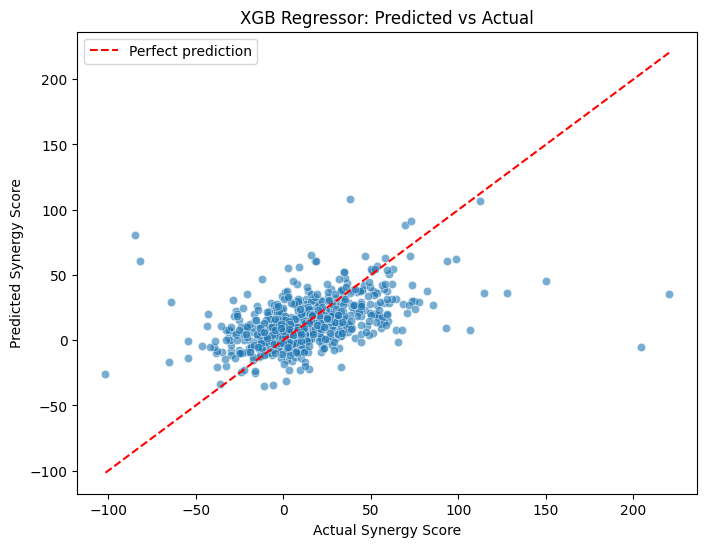

In [ ]:
#get best model
best_model = models["XGB Regressor"]
y_pred = best_model.predict(X_test_transformed)

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)

#prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label="Perfect prediction"
)

plt.xlabel("Actual Synergy Score")
plt.ylabel("Predicted Synergy Score")
plt.title("XGB Regressor: Predicted vs Actual")
plt.legend()
plt.show()

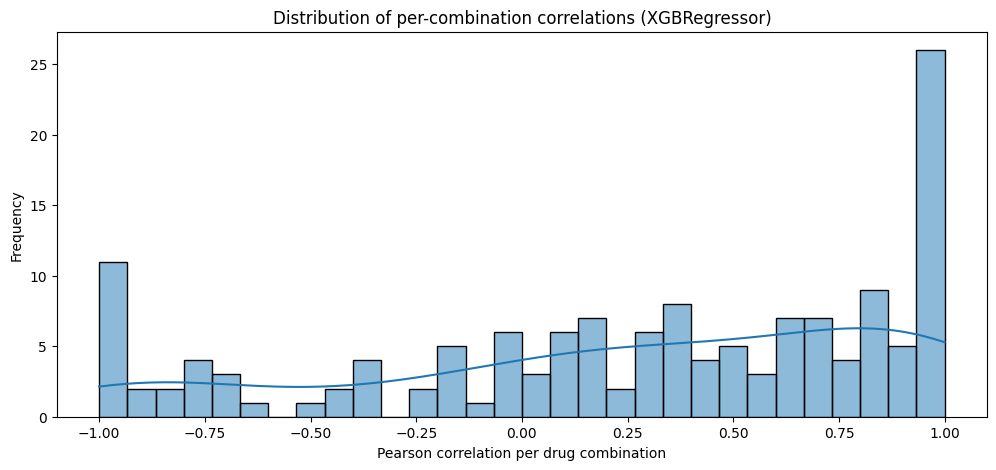

In [ ]:
import numpy as np

#combination column from original data
combo_test = X_test['Compound A'].astype(str) + "+" + X_test['Compound B'].astype(str)

df_eval = pd.DataFrame({
    'Combination': combo_test,
    'Actual': y_test.values,
    'Predicted': y_pred
})

#safer correlation
def safe_corr(g):
    if len(g) <= 1:
        return np.nan
    if g['Actual'].nunique() <= 1 or g['Predicted'].nunique() <= 1:
        return np.nan
    return np.corrcoef(g['Actual'], g['Predicted'])[0,1]

combo_corrs = df_eval.groupby('Combination').apply(safe_corr)

plt.figure(figsize=(12,5))
sns.histplot(combo_corrs.dropna(), bins=30, kde=True)

plt.xlabel("Pearson correlation per drug combination")
plt.ylabel("Frequency")
plt.title("Distribution of per-combination correlations (XGBRegressor)")
plt.show()

/var/folders/hv/6ybt4x7x2fv00t19qtjfczw40000gn/T/ipykernel_48502/560751149.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


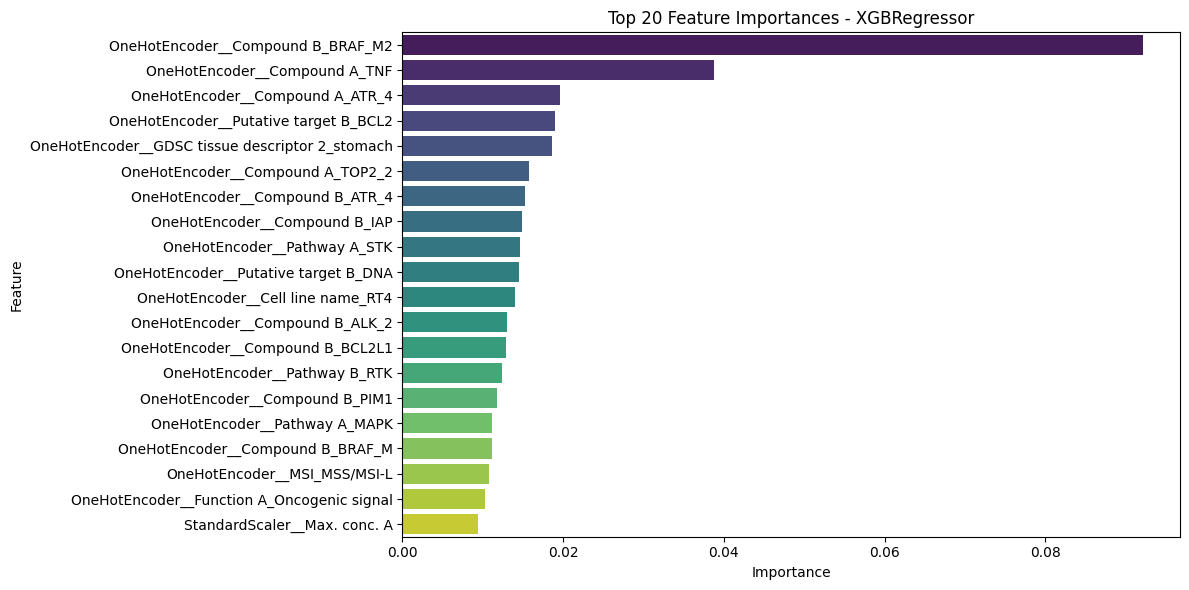

In [18]:
# get feature names from preprocessor
feature_names = preprocessor.get_feature_names_out()

# XGB feature importances
importances = best_model.feature_importances_

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feat_imp_df.head(20),
    palette='viridis'
)

plt.title("Top 20 Feature Importances - XGBRegressor")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()